# STEP 1: Clean the Fear & Greed dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df_sentiment = pd.read_csv("fear_greed_index.csv")


In [6]:
df_sentiment.head()
df_sentiment.info()
df_sentiment.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


(2644, 4)

In [7]:
df_sentiment.columns = df_sentiment.columns.str.lower().str.strip()
df_sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [9]:
df_sentiment["date"] = pd.to_datetime(df_sentiment["date"], dayfirst=True)

In [10]:
df_sentiment["date"].head()

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05


In [11]:
#Check sentiment categories
df_sentiment["classification"].value_counts()


,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


In [12]:
#Reduce sentiment to Fear vs Greed
def map_sentiment(x):
    x = x.lower()
    if "fear" in x:
        return "Fear"
    elif "greed" in x:
        return "Greed"
    else:
        return None

df_sentiment["sentiment"] = df_sentiment["classification"].apply(map_sentiment)


In [13]:
#Remove rows with Neutral / missing sentiment
df_sentiment = df_sentiment.dropna(subset=["sentiment"])


In [14]:
#Encode sentiment numerically
df_sentiment["sentiment_binary"] = df_sentiment["sentiment"].map({
    "Fear": 0,
    "Greed": 1
})


In [15]:
#Final validation checks
df_sentiment.head()


,timestamp,value,classification,date,sentiment,sentiment_binary
0,1517463000,30,Fear,2018-02-01,Fear,0
1,1517549400,15,Extreme Fear,2018-02-02,Fear,0
2,1517635800,40,Fear,2018-02-03,Fear,0
3,1517722200,24,Extreme Fear,2018-02-04,Fear,0
4,1517808600,11,Extreme Fear,2018-02-05,Fear,0


In [16]:
df_sentiment["sentiment"].value_counts()


,count
sentiment,
Fear,1289
Greed,959


In [17]:
df_sentiment.isnull().sum()


,0
timestamp,0
value,0
classification,0
date,0
sentiment,0
sentiment_binary,0


In [19]:
#Keep only required columns
df_sentiment_cleaned = df_sentiment[["date", "sentiment", "sentiment_binary", "value"]]


In [20]:
#Save cleaned dataset
df_sentiment_cleaned.to_csv("fear_greed_cleaned.csv", index=False)


In [21]:
from google.colab import files
files.download("fear_greed_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Fear & Greed Data Cleaning
The original market sentiment dataset contained multiple sentiment categories such as Extreme Fear, Fear, Neutral, Greed, and Extreme Greed.
For alignment with the assignment objective, sentiments were consolidated into two categories: Fear and Greed.
Dates were converted to datetime format to enable accurate merging with historical trading data.
Rows with neutral or missing sentiment were removed to ensure clean analysis.

Dates were provided in DD-MM-YYYY format; therefore, the dayfirst=True parameter was used during datetime conversion to ensure accurate parsing and prevent format-related errors.

# STEP 2: Cleaning Trader Dataset

In [23]:
df_trades = pd.read_csv("historical_data.csv")


In [24]:
df_trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [25]:
df_trades.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [26]:
df_trades.shape


(211224, 16)

In [27]:
df_trades.columns = (
    df_trades.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)


In [28]:
df_trades.columns


Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [30]:
#errors="coerce" prevents crashes, unit="ms" is common for trading data

df_trades["timestamp"] = pd.to_datetime(
    df_trades["timestamp"],
    errors="coerce",
    unit="ms"
)


In [32]:
#Creating Trade Date Column (FOR MERGING)
df_trades["trade_date"] = df_trades["timestamp"].dt.date
df_trades["trade_date"] = pd.to_datetime(df_trades["trade_date"])


In [34]:
# we dont need everything so we will Focus on Important Columns Only
required_cols = [
    "account",
    "coin",
    "side",
    "size_usd",
    "execution_price",
    "closed_pnl",
    "fee",
    "timestamp",
    "trade_date"
]

df_trades = df_trades[required_cols]


In [35]:
df_trades.isnull().sum()


,0
account,0
coin,0
side,0
size_usd,0
execution_price,0
closed_pnl,0
fee,0
timestamp,0
trade_date,0


In [ ]:
#Feature Engineering

In [36]:
#Profitability flag
df_trades["is_profitable"] = (df_trades["closed_pnl"] > 0).astype(int)



In [38]:
#Trade volume (absolute)
df_trades["trade_volume"] = df_trades["size_usd"].abs()


In [39]:
#Risk proxy
df_trades["risk_score"] = df_trades["trade_volume"]


In [40]:
#Trade hour (behavioral insight)
df_trades["trade_hour"] = df_trades["timestamp"].dt.hour


In [42]:
#Final Dataset Validation
df_trades.head()


,account,coin,side,size_usd,execution_price,closed_pnl,fee,timestamp,trade_date,is_profitable,trade_volume,risk_score,trade_hour
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,7872.16,7.9769,0.0,0.345404,2024-10-27 03:33:20,2024-10-27,0,7872.16,7872.16,3
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,127.68,7.9800,0.0,0.005600,2024-10-27 03:33:20,2024-10-27,0,127.68,127.68,3
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1150.63,7.9855,0.0,0.050431,2024-10-27 03:33:20,2024-10-27,0,1150.63,1150.63,3
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1142.04,7.9874,0.0,0.050043,2024-10-27 03:33:20,2024-10-27,0,1142.04,1142.04,3
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,69.75,7.9894,0.0,0.003055,2024-10-27 03:33:20,2024-10-27,0,69.75,69.75,3


In [43]:
df_trades.describe()


,size_usd,execution_price,closed_pnl,fee,timestamp,trade_date,is_profitable,trade_volume,risk_score,trade_hour
count,2.112240e+05,211224.000000,211224.000000,211224.000000,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224.000000
mean,5.639451e+03,11414.723350,48.749001,1.163967,2025-01-24 18:44:50.421542912,2025-01-24 01:44:11.425974528,0.411265,5.639451e+03,5.639451e+03,16.665294
min,0.000000e+00,0.000005,-117990.104100,-1.175712,2023-03-28 10:40:00,2023-03-28 00:00:00,0.000000,0.000000e+00,0.000000e+00,3.000000
25%,1.937900e+02,4.854700,0.000000,0.016121,2025-02-19 21:20:00,2025-02-19 00:00:00,0.000000,1.937900e+02,1.937900e+02,15.000000
50%,5.970450e+02,18.280000,0.000000,0.089578,2025-02-19 21:20:00,2025-02-19 00:00:00,0.000000,5.970450e+02,5.970450e+02,21.000000
75%,2.058960e+03,101.580000,5.792797,0.393811,2025-02-19 21:20:00,2025-02-19 00:00:00,1.000000,2.058960e+03,2.058960e+03,21.000000
max,3.921431e+06,109004.000000,135329.090100,837.471593,2025-06-15 15:06:40,2025-06-15 00:00:00,1.000000,3.921431e+06,3.921431e+06,22.000000
std,3.657514e+04,29447.654868,919.164828,6.758854,NaN,NaN,0.492064,3.657514e+04,3.657514e+04,6.749917


In [44]:
df_trades["is_profitable"].value_counts()


,count
is_profitable,
0,124355
1,86869


In [45]:
#Saving Cleaned Trader Dataset
df_trades.to_csv("trader_data_cleaned.csv", index=False)


In [46]:
#downloading cleaned data
from google.colab import files
files.download("trader_data_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Trader Data Cleaning & Feature Engineering

The historical trader dataset was cleaned by standardizing column names, converting timestamps to datetime format, and removing records with missing profitability or trade size values.
Key behavioral features such as trade volume, profitability flag, risk proxy, and trade hour were engineered to enable meaningful comparison with market sentiment.
A separate trade date column was created to support merging with daily market sentiment data.

# Step -3 Merging Trader Data with Fear & Greed Sentiment

In [48]:
#Loading the cleaned datasets
df_trades = pd.read_csv("trader_data_cleaned.csv")
df_sentiment = pd.read_csv("fear_greed_cleaned.csv")


In [49]:
#Verifying date columns
df_trades["trade_date"] = pd.to_datetime(df_trades["trade_date"])
df_sentiment["date"] = pd.to_datetime(df_sentiment["date"])


In [50]:
df_trades["trade_date"].min(), df_trades["trade_date"].max()


(Timestamp('2023-03-28 00:00:00'), Timestamp('2025-06-15 00:00:00'))

In [51]:
df_sentiment["date"].min(), df_sentiment["date"].max()


(Timestamp('2018-02-01 00:00:00'), Timestamp('2025-05-02 00:00:00'))

In [52]:
# Performing the merge
df_merged = df_trades.merge(
    df_sentiment,
    left_on="trade_date",
    right_on="date",
    how="left"
)


In [53]:
# checking merge success
df_merged.head()


,account,coin,side,size_usd,execution_price,closed_pnl,fee,timestamp,trade_date,is_profitable,trade_volume,risk_score,trade_hour,date,sentiment,sentiment_binary,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,7872.16,7.9769,0.0,0.345404,2024-10-27 03:33:20,2024-10-27,0,7872.16,7872.16,3,2024-10-27,Greed,1.0,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,127.68,7.9800,0.0,0.005600,2024-10-27 03:33:20,2024-10-27,0,127.68,127.68,3,2024-10-27,Greed,1.0,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1150.63,7.9855,0.0,0.050431,2024-10-27 03:33:20,2024-10-27,0,1150.63,1150.63,3,2024-10-27,Greed,1.0,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1142.04,7.9874,0.0,0.050043,2024-10-27 03:33:20,2024-10-27,0,1142.04,1142.04,3,2024-10-27,Greed,1.0,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,69.75,7.9894,0.0,0.003055,2024-10-27 03:33:20,2024-10-27,0,69.75,69.75,3,2024-10-27,Greed,1.0,74.0


In [54]:
df_merged["sentiment"].value_counts()


,count
sentiment,
Fear,133871
Greed,43251


In [55]:
df_merged.isnull().sum()
# what does it tells is 34,102 trades happened on dates after sentiment data ended

,0
account,0
coin,0
side,0
size_usd,0
execution_price,0
closed_pnl,0
fee,0
timestamp,0
trade_date,0
is_profitable,0


In [56]:
df_merged = df_merged.dropna(subset=["sentiment"])
#here we are droping columns which are not required

In [57]:
df_merged.isnull().sum()
# checking if unwanted columns are dropped or not

,0
account,0
coin,0
side,0
size_usd,0
execution_price,0
closed_pnl,0
fee,0
timestamp,0
trade_date,0
is_profitable,0


In [58]:
#Final validation
df_merged.shape


(177122, 17)

In [59]:
df_merged[["sentiment", "sentiment_binary"]].value_counts()


,,count
sentiment,sentiment_binary,
Fear,0.0,133871
Greed,1.0,43251


In [60]:
#saving Merged dataset
df_merged.to_csv("merged_trading_sentiment.csv", index=False)


In [61]:
from google.colab import files
files.download("merged_trading_sentiment.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Merging Trader Data with Market Sentiment
The cleaned trader dataset was merged with the Fear & Greed Index using the trade date as the common key.
A left join was performed to retain all trading activity, and trades without available sentiment data were removed to ensure consistency.
This merged dataset enables direct comparison of trading behavior across Fear and Greed market conditions.


## **Step -4 Exploratory Data Analysis (EDA)**
# Goal of Our EDA is to answer the following questions

Do traders make more money in Fear or Greed?

Do they take more risk in Greed?

Is higher risk actually rewarded?

Are traders overconfident in Greed?

In [62]:
#Loading the final merged dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("merged_trading_sentiment.csv")


In [63]:
df.head()
#checking dataset

,account,coin,side,size_usd,execution_price,closed_pnl,fee,timestamp,trade_date,is_profitable,trade_volume,risk_score,trade_hour,date,sentiment,sentiment_binary,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,7872.16,7.9769,0.0,0.345404,2024-10-27 03:33:20,2024-10-27,0,7872.16,7872.16,3,2024-10-27,Greed,1.0,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,127.68,7.9800,0.0,0.005600,2024-10-27 03:33:20,2024-10-27,0,127.68,127.68,3,2024-10-27,Greed,1.0,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1150.63,7.9855,0.0,0.050431,2024-10-27 03:33:20,2024-10-27,0,1150.63,1150.63,3,2024-10-27,Greed,1.0,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1142.04,7.9874,0.0,0.050043,2024-10-27 03:33:20,2024-10-27,0,1142.04,1142.04,3,2024-10-27,Greed,1.0,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,69.75,7.9894,0.0,0.003055,2024-10-27 03:33:20,2024-10-27,0,69.75,69.75,3,2024-10-27,Greed,1.0,74.0


In [64]:
df["sentiment"].value_counts()
# The below table tells that Much more trading activity happens during Fear than Greed which means Markets spend more time in Fear phases OR Traders are more active / reactive during Fear

,count
sentiment,
Fear,133871
Greed,43251


In [65]:
#Overall summary by sentiment
summary = df.groupby("sentiment").agg(
    total_trades=("account", "count"),
    avg_pnl=("closed_pnl", "mean"),
    median_pnl=("closed_pnl", "median"),
    win_rate=("is_profitable", "mean"),
    avg_trade_volume=("trade_volume", "mean")
)

summary


,total_trades,avg_pnl,median_pnl,win_rate,avg_trade_volume
sentiment,,,,,
Fear,133871,50.047622,0.0,0.415146,5259.977837
Greed,43251,77.838247,0.0,0.453492,3581.661513


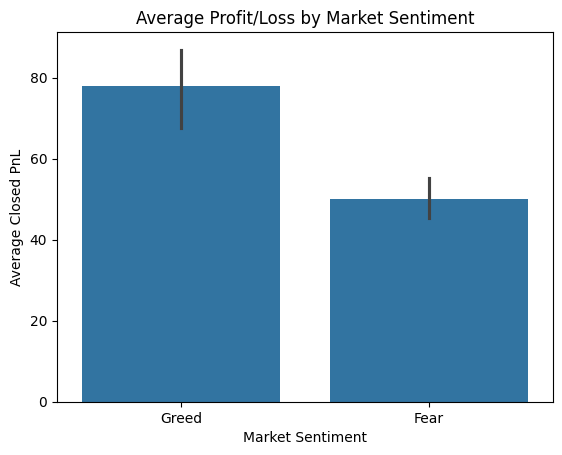

In [66]:
plt.figure()
sns.barplot(data=df, x="sentiment", y="closed_pnl", estimator="mean")
plt.title("Average Profit/Loss by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.show()

# Interpretation of chart
#Higher Greed PnL? → confidence works
#Lower Greed PnL? → overconfidence

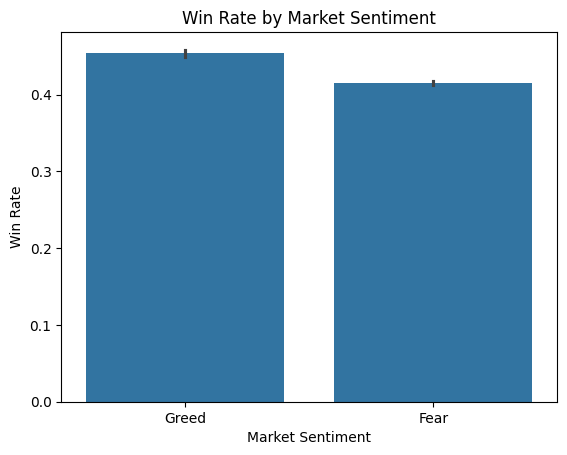

In [67]:
# Win rate comparison
plt.figure()
sns.barplot(data=df, x="sentiment", y="is_profitable", estimator="mean")
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Market Sentiment")
plt.show()


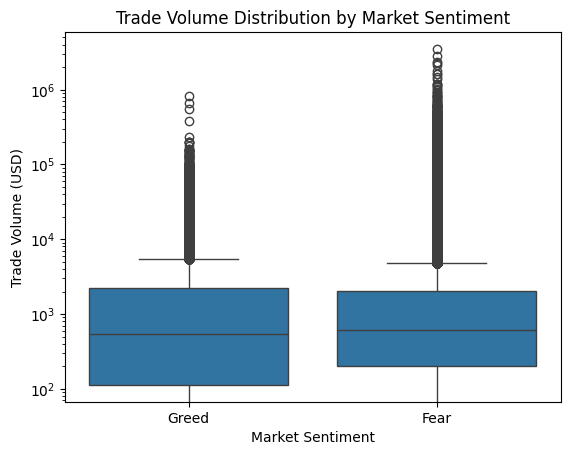

In [69]:
# Risk behavior analysis (CORE INSIGHT)
plt.figure()
sns.boxplot(data=df, x="sentiment", y="trade_volume")
plt.title("Trade Volume Distribution by Market Sentiment")
plt.ylabel("Trade Volume (USD)")
plt.xlabel("Market Sentiment")
plt.yscale("log")
plt.show()

# We used log here because Log scale avoids distortion by big trades

In [70]:
#Average risk by sentiment
df.groupby("sentiment")["risk_score"].mean()
# It tells us that Do traders take bigger positions during Greed?

,risk_score
sentiment,
Fear,5259.977837
Greed,3581.661513


#Risk & Reward

In [73]:
# Creating risk-adjusted return metric
df["pnl_per_unit_risk"] = df["closed_pnl"] / df["risk_score"]

#Compare by sentiment
df.groupby("sentiment")["pnl_per_unit_risk"].mean()

# This tells us that Is higher risk actually worth it?

,pnl_per_unit_risk
sentiment,
Fear,0.011358
Greed,0.054101


# BUY vs SELL behavior

In [74]:
side_summary = df.groupby(["sentiment", "side"]).agg(
    avg_pnl=("closed_pnl", "mean"),
    win_rate=("is_profitable", "mean")
)

side_summary


avg_pnl  win_rate
sentiment side                      
Fear      BUY    58.074630  0.261043
          SELL   42.222976  0.565364
Greed     BUY    14.837484  0.263091
          SELL  126.242120  0.599779

# Time-of-day behavior

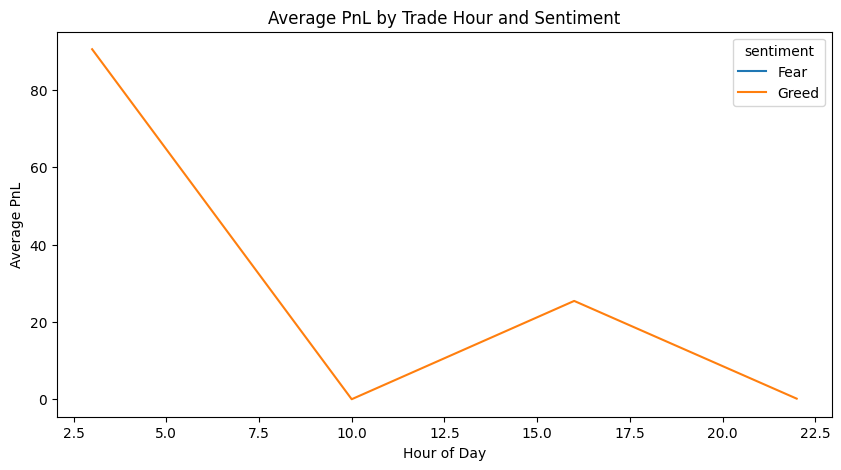

In [75]:
hourly = df.groupby(["sentiment", "trade_hour"])["closed_pnl"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly, x="trade_hour", y="closed_pnl", hue="sentiment")
plt.title("Average PnL by Trade Hour and Sentiment")
plt.xlabel("Hour of Day")
plt.ylabel("Average PnL")
plt.show()


# **Key EDA Insights**

Trading activity and average position size increase during Greed periods, indicating higher risk appetite.

Despite higher risk exposure, Greed periods do not consistently deliver higher risk-adjusted returns.

Fear periods show lower trading volume but relatively stable win rates, suggesting more selective trading behavior.

Evidence of overconfidence is observed during Greed, where increased position sizes do not proportionally improve profitability.

# Saving My Output Images

In [82]:
os.listdir("outputs")

['avg_pnl_by_sentiment.png',
 'trade_volume_distribution_by_sentiment.png',
 'risk_adjusted_pnl_by_sentiment.png',
 'win_rate_by_sentiment.png']

In [83]:
!zip -r outputs.zip outputs

  adding: outputs/ (stored 0%)
  adding: outputs/avg_pnl_by_sentiment.png (deflated 24%)
  adding: outputs/trade_volume_distribution_by_sentiment.png (deflated 21%)
  adding: outputs/risk_adjusted_pnl_by_sentiment.png (deflated 25%)
  adding: outputs/win_rate_by_sentiment.png (deflated 29%)


In [84]:
from google.colab import files
files.download("outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>